## Monte Carlo Spin Dynamics

In [2]:
using LinearAlgebra, Random, Statistics, Dates, Printf, LaTeXStrings, Colors, JLD, Plots, LsqFit
include("Markov_chain.jl")
include("Covariance_method.jl");

In [3]:
@doc Metropolis

The `Metropolis` algorithm constructs a new spin configuration. When applied multiple times it can be used in a `Markov_chain` (see function below).

##### Input parameters of `Metropolis`:

  * `β::Float64` : β = J/kT dimensionless coupling constant
  * `b::Float64` : b = μB/kT dimensionless external magnetic field
  * `s::Array{Int64}`  : D-dim Array with N Spins of +1 or -1 in each direction

##### Output values:

  * `s::Array{Int64}`  : D-dim Array with new configuration of the N Spins in each direction


**Thermalization Time**

First we check the qualitative behavior of the Markov chain and read off the thermalization time $N_\text{th}$.

In [4]:
N::Int64 = 100
D::Int64 = 2

β::Float64 = 0.43
b::Float64 = 0.01
N_config::Int64 = 1e4

#Random.seed!(123)
M, E = Markov_chain(β, b, N, D, "hot", N_config);

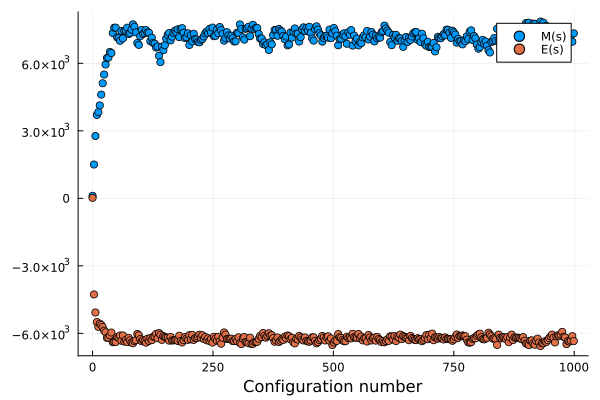

In [5]:
plot_history(1000, M, E; skip=2)

**Error Estimation**

Using the Markov chain generated above, we calculate $\delta(W)$ and plot it as a function of $W$.

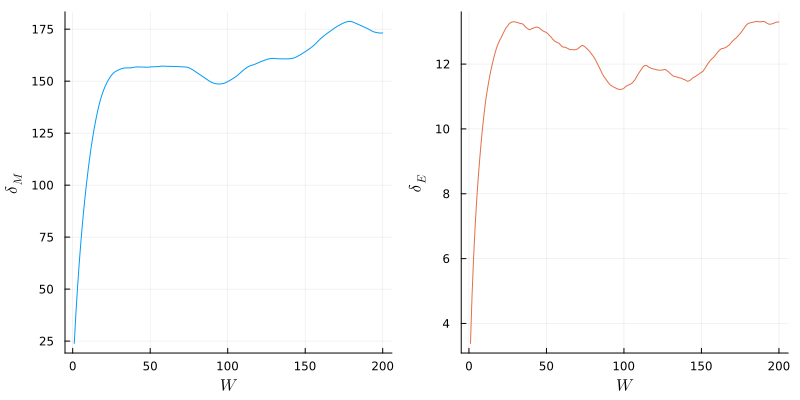

In [6]:
N_th::Int64 = 300
W_max::Int64 = 200

ΔM, ΔE = [], []
for W in 1:W_max
    ΔM = vcat(ΔM, δ(M, N_th, W))
    ΔE = vcat(ΔE, δ(E, N_th, W))
end

p_1 = plot(collect(1:W_max), ΔM, label = "")
xlabel!(L"W"); ylabel!(L"\delta_M")
p_2 = plot(collect(1:W_max), ΔE, color = 2, label = "")
xlabel!(L"W"); ylabel!(L"\delta_E")

p = plot(p_1, p_2, layout = (1,2), size = (800,400), left_margin = 3Plots.mm, bottom_margin = 3Plots.mm)
display(p)

For small $W$ both $\delta_M(W)$ and $\delta_E(W)$ increase monotonely, but at larger values they begin to fluctuate due to the random contributions from uncorrelated (far apart) configurations in the sum.

In [7]:
#Determine mean values using the covariance method
tol::Float64 = 0.02

M_res = covariance_method(M, N_th, 100; verbose = true, tol = tol)
@printf "⟨M⟩ = %.4e ± %.4e\n" M_res...

E_res = covariance_method(E, N_th, 100; verbose = true, tol = tol)
@printf "⟨E⟩ = %.4e ± %.4e" E_res...

W_bar = 18
⟨M⟩ = 7.1740e+03 ± 1.1888e+01
W_bar = 14
⟨E⟩ = -6.2334e+03 ± 3.4312e+00

To show that the error decreases, we calculate it for increasing $N_\text{config}$.

In [31]:
N_range = Int.(collect(1e4:1e4:1e5));

In [32]:
#This cell can be skipped!

M_res, E_res = [], []

for N_config in N_range
    M, E = Markov_chain(β, b, N, D, "hot", N_config)
    M_res = vcat(M_res, covariance_method(M, N_th, W_max; tol = tol))
    E_res = vcat(E_res, covariance_method(E, N_th, W_max; tol = tol))
end

@save "data_N_config.jld" M_res E_res

The statistical errors decrease as $1/\sqrt{N_\text{config}-N_\text{th}}$:

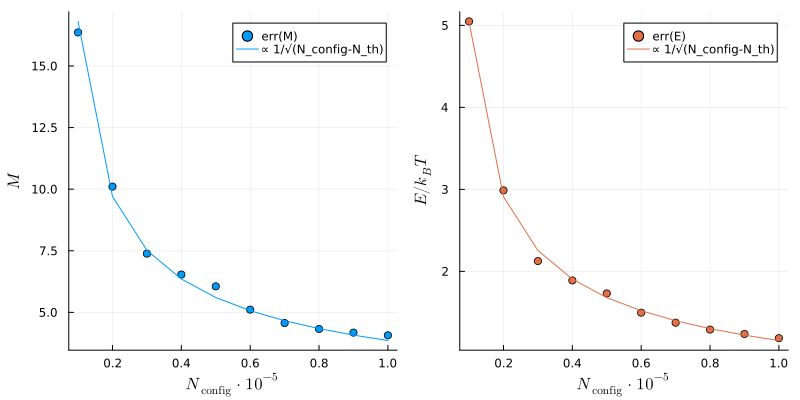

In [33]:
@load "data_N_config.jld" M_res E_res
f(N_range, p) = @. p[1]/sqrt(N_range-N_th)

p_1 = scatter(N_range*1e-5, map(x -> x[2], M_res), label = "err(M)")
fit_1 = curve_fit(f, N_range, map(x -> x[2], M_res), [1.0])
plot!(N_range*1e-5, f(N_range, fit_1.param[1]), color = 1, label = "∝ 1/√(N_config-N_th)")
xlabel!(L"N_\textrm{config}\cdot 10^{-5}"); ylabel!(L"M")

p_2 = scatter(N_range*1e-5, map(x -> x[2], E_res), color = 2, label = "err(E)")
fit_2 = curve_fit(f, N_range, map(x -> x[2], E_res), [1.0])
plot!(N_range*1e-5, f(N_range, fit_2.param[1]), color = 2, label = "∝ 1/√(N_config-N_th)")
xlabel!(L"N_\textrm{config}\cdot 10^{-5}"); ylabel!(L"E/k_BT")

p = plot(p_1, p_2, layout = (1,2), size = (800,400), left_margin = 3Plots.mm, bottom_margin = 3Plots.mm)
display(p)

**Phase Transition**

First we choose the range of values for $\beta$ and $b$ we want to cover:

In [27]:
N_config::Int64 = 1.2e4
steps::Int64 = 20

β_range = range(0.3, 10, steps).^-1
b_range = [0.1, 0.05, 0.01];

Now we calculate $\langle M\rangle$ and $\langle E\rangle$ for all parameter combinations.

In [28]:
#This cell can be skipped!

M_res = zeros((length(β_range), length(b_range), N_config+1))
E_res = zeros((length(β_range), length(b_range), N_config+1))

for i in 1:length(β_range)
    for j in 1:length(b_range)
        R = Markov_chain(β_range[i], b_range[j], N, D, "hot", N_config)
        M_res[i, j, :] = R[1]
        E_res[i, j, :] = R[2]
    end
end

@save "data_phase_transition.jld" M_res E_res

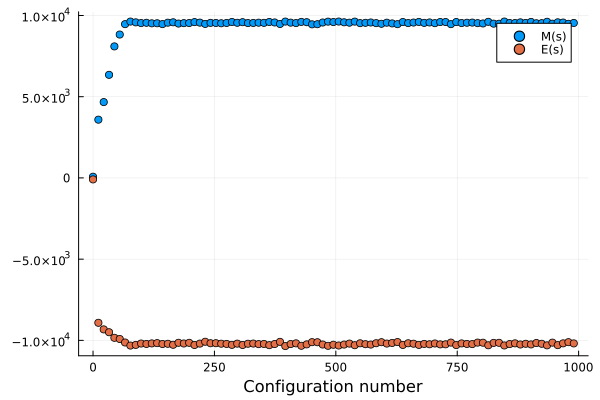

In [29]:
#Check thermalization time for low temperature & low external field
i, j = 4, 3
plot_history(1000, M_res[i, j, :], E_res[i, j, :]; skip=10)

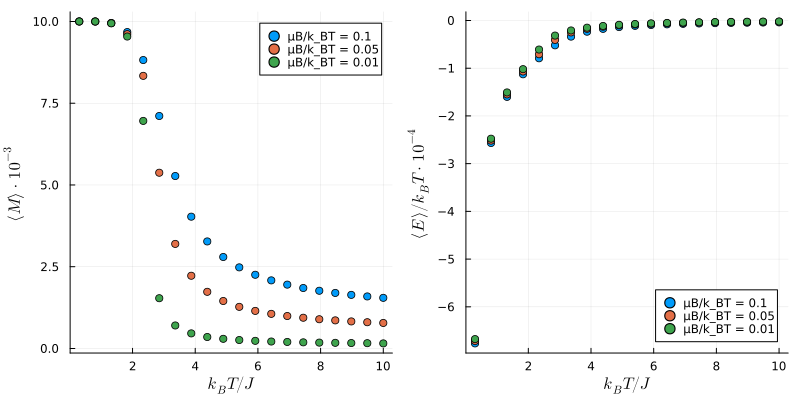

In [30]:
@load "data_phase_transition.jld" M_res E_res

N_th::Int64 = 5e3

p_1 = plot()
xlabel!(L"k_BT/J"); ylabel!(L"\langle M\rangle\cdot 10^{-3}")
p_2 = plot()
xlabel!(L"k_BT/J"); ylabel!(L"\langle E\,\rangle/k_BT\cdot 10^{-4}")

for j in 1:length(b_range)
    M_range = [mean(M_res[i, j, N_th+1:end]) for i in 1:length(β_range)]
    E_range = [mean(E_res[i, j, N_th+1:end]) for i in 1:length(β_range)]
    scatter!(p_1, β_range.^-1, 1e-3*M_range, label = "μB/k_BT = " * string(b_range[j]))
    scatter!(p_2, β_range.^-1, 1e-4*E_range, label = "μB/k_BT = " * string(b_range[j]))
end

p = plot(p_1, p_2, layout = (1,2), size = (800,400), left_margin = 3Plots.mm, bottom_margin = 3Plots.mm)